
# ===========================================
# qPCR Sample Analysis Pipeline
# Phase I - Import and Validation
# Author: Gabi Rivera
# Start Date: 25Jun2026
# ===========================================

#### Imported Libraries

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install klib

import klib

#### Handle Warnings

## Load QuantStudio 5 Dataset

### GitHub Repository

In [2]:
# Clone the GitHub Repository (Colab only)
if IN_COLAB:
    !git clone https://github.com/GabiRivera0011/resiDNA_workflows.git

In [3]:
# Set the project path
if IN_COLAB:
    project_path = Path("/content/resiDNA_workflows")
else:
    # Running locally: cwd is usually Notebooks/, repo root is its parent
    project_path = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()

data_path = project_path / "Data"
notebook_path = project_path / "Notebooks"

print(project_path)

C:\Users\budar\Desktop\resiDNA_workflows


In [4]:
# Verify the Data exist
list(data_path.iterdir())

[WindowsPath('C:/Users/budar/Desktop/resiDNA_workflows/Data/.gitkeep'),
 WindowsPath('C:/Users/budar/Desktop/resiDNA_workflows/Data/experiment_001.xlsx')]

In [5]:
# Load the excel workbook
file = data_path / "experiment_001.xlsx"
xls = pd.ExcelFile(file)
xls.sheet_names

['Sample Setup',
 'Results',
 'Amplification Data',
 'STD Curve',
 'NC',
 'PC',
 'S1_HIC']

### Dataset = df

In [6]:
# Read the desired worksheet or tab
df = pd.read_excel(
    file,
    sheet_name="Results",
    header=22
)

#### Table Styling Helper

In [7]:
# Consistent, presentation-ready styling for all tables in this notebook
# Colors are explicit so tables render in light mode regardless of the editor/notebook theme
def style_table(data, caption="", hide_index=True, precision=4, align="center",
                highlight_rows=None, highlight_color="#D4EDDA"):
    styler = data.style.set_caption(caption)

    if highlight_rows is not None:
        def _highlight(row):
            if highlight_rows.loc[row.name]:
                return [f"background-color: {highlight_color} !important"] * len(row)
            return [""] * len(row)

        styler = styler.apply(_highlight, axis=1)

    if hide_index:
        styler = styler.hide(axis="index")

    styler = styler.format(precision=precision, na_rep="—")

    styler = styler.set_table_attributes(
        'style="background-color:#FFFFFF; border-collapse:collapse;"'
    )

    styler = styler.set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-size", "13pt"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("padding", "4px 0 8px 0"),
            ("color", "#2C3E50"),
            ("background-color", "#FFFFFF"),
        ]},
        {"selector": "th", "props": [
            ("background-color", "#2C3E50"),
            ("color", "#FFFFFF"),
            ("font-weight", "bold"),
            ("text-align", align),
            ("padding", "6px 12px"),
            ("border", "1px solid #2C3E50"),
        ]},
        {"selector": "td", "props": [
            ("padding", "6px 12px"),
            ("border", "1px solid #DDDDDD"),
            ("text-align", align),
            ("color", "#2C2C2C"),
            ("background-color", "#FFFFFF"),
        ]},
        {"selector": "tr:nth-child(even) td", "props": [
            ("background-color", "#F7F9FA"),
        ]},
    ])

    return styler

### MetaData

In [8]:
# Capture Metadata
metadata_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    nrows=19
)

# Keep only the first two columns (Field and Value)
metadata_table = metadata_df.iloc[:, :2].copy()

# Rename columns
metadata_table.columns = ["Field", "Value"]

# Remove completely empty rows
metadata_table = metadata_table.dropna(how="all")

# Display the table
style_table(metadata_table, caption="Experiment Metadata", align="left")

Field,Value
Experiment Details:,—
Block Type:,0.1 mL
Chemistry:,TAQMAN
Date Created:,17 Jul 2026 11:00:56 GMT-0700
Barcode:,—
Comments:,Update protein concentration Correct dilutions Correct spike information For HCCP and ProA
Experiment Name:,2026-07-17_MD_R3_GR
Experiment Run End Time:,17 Jul 2026 16:14:21 GMT-0700
Experiment Type:,Standard Curve
Instrument Name:,272513207


### Regression Line Info

In [9]:
# Regression Line
regression_df = pd.read_excel(
    file,
    sheet_name="Results",
    header=None,
    skiprows=18,
    nrows=1,
    usecols="C:G"
)

# Convert to a tidy DataFrame
regression_stats = []

for item in regression_df.iloc[0]:
    if pd.notna(item):
        key, value = str(item).split(":", 1)
        regression_stats.append({
            "Metric": key.strip(),
            "Value": value.strip()
        })

regression_table = pd.DataFrame(regression_stats)

style_table(regression_table, caption="Standard Curve Regression Statistics", align="left")

Metric,Value
R2,0.9998
Slope,-3.3008
y-Intercept,21.3153
Efficiency,100.89
Std error,0.0116


### Exploratory Data Analysis

In [10]:
# Dataset Table
style_table(df.head(), caption="Raw Dataset Preview (Results Sheet)")

Well,Well Position,Task,Sample Name,Target Name,Ct,Ct Mean,Ct CV%,Ct SD,Quantity,Quantity Mean,Quantity SD,Quantity %CV,Dilution Factor,Dilution Adjusted,% Recovery,R2,Slope,Y-Intercept,Total DNA per mL,Total DNA per Protein Concentration,Flag,Ct Threshold,Automatic Ct Threshold,CQ Confidence,Automatic Baseline,Baseline Start,Baseline End,Reference,Reference Adjusted,Spike Input,Back calculated value,Back Calculation Mean,Back Calculation %CV,Back Calculation SD,Back Calculation % difference,Back Calculation % difference Mean,Fit,Amplification Efficiency,Amplification Status,AMPNC,NOAMP,EXPFAIL,Protein Concentration,CQCONF
A1,1,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.0000,—,—,0.9998,-3.3008,21.3153,0.0000,—,0.0000,0.2070,True,0.0000,Yes,3.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,Linear,100.8900,No Amp,N,N,N,—,N
A2,2,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.0000,—,—,0.9998,-3.3008,21.3153,0.0000,—,0.0000,0.2070,True,0.0000,Yes,3.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,Linear,100.8900,No Amp,N,N,N,—,N
A3,3,NTC,NTC,CHO,Undetermined,—,—,—,—,—,—,—,1.0000,—,—,0.9998,-3.3008,21.3153,0.0000,—,0.0000,0.2070,True,0.0000,Yes,3.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,Linear,100.8900,No Amp,N,N,N,—,N
A4,4,UNKNOWN,S1 D1,CHO,32.3647,32.5183,0.8100,0.2622,0.0004,0.0004,0.0001,17.2400,1.0000,0.0004,—,0.9998,-3.3008,21.3153,0.0004,0.0002,0.0000,0.2070,True,1.0000,Yes,3.0000,27.0000,0.0000,0.0004,0.0000,—,—,—,—,—,—,Linear,100.8900,Amplification,N,N,N,1.8250,N
A5,5,UNKNOWN,S1 D1,CHO,32.3692,32.5183,0.8100,0.2622,0.0004,0.0004,0.0001,17.2400,1.0000,0.0004,—,0.9998,-3.3008,21.3153,0.0004,0.0002,0.0000,0.2070,True,1.0000,Yes,3.0000,28.0000,0.0000,0.0004,0.0000,—,—,—,—,—,—,Linear,100.8900,Amplification,N,N,N,1.8250,N


In [11]:
# Dataset General Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Well                                 96 non-null     str    
 1   Well Position                        96 non-null     int64  
 2   Task                                 69 non-null     str    
 3   Sample Name                          69 non-null     str    
 4   Target Name                          69 non-null     str    
 5   Ct                                   69 non-null     object 
 6   Ct Mean                              55 non-null     float64
 7   Ct CV%                               54 non-null     float64
 8   Ct SD                                54 non-null     float64
 9   Quantity                             55 non-null     float64
 10  Quantity Mean                        37 non-null     float64
 11  Quantity SD                          36 non-n

GridSpec(6, 6)

findfont: Failed to find font weight light, now using 400.


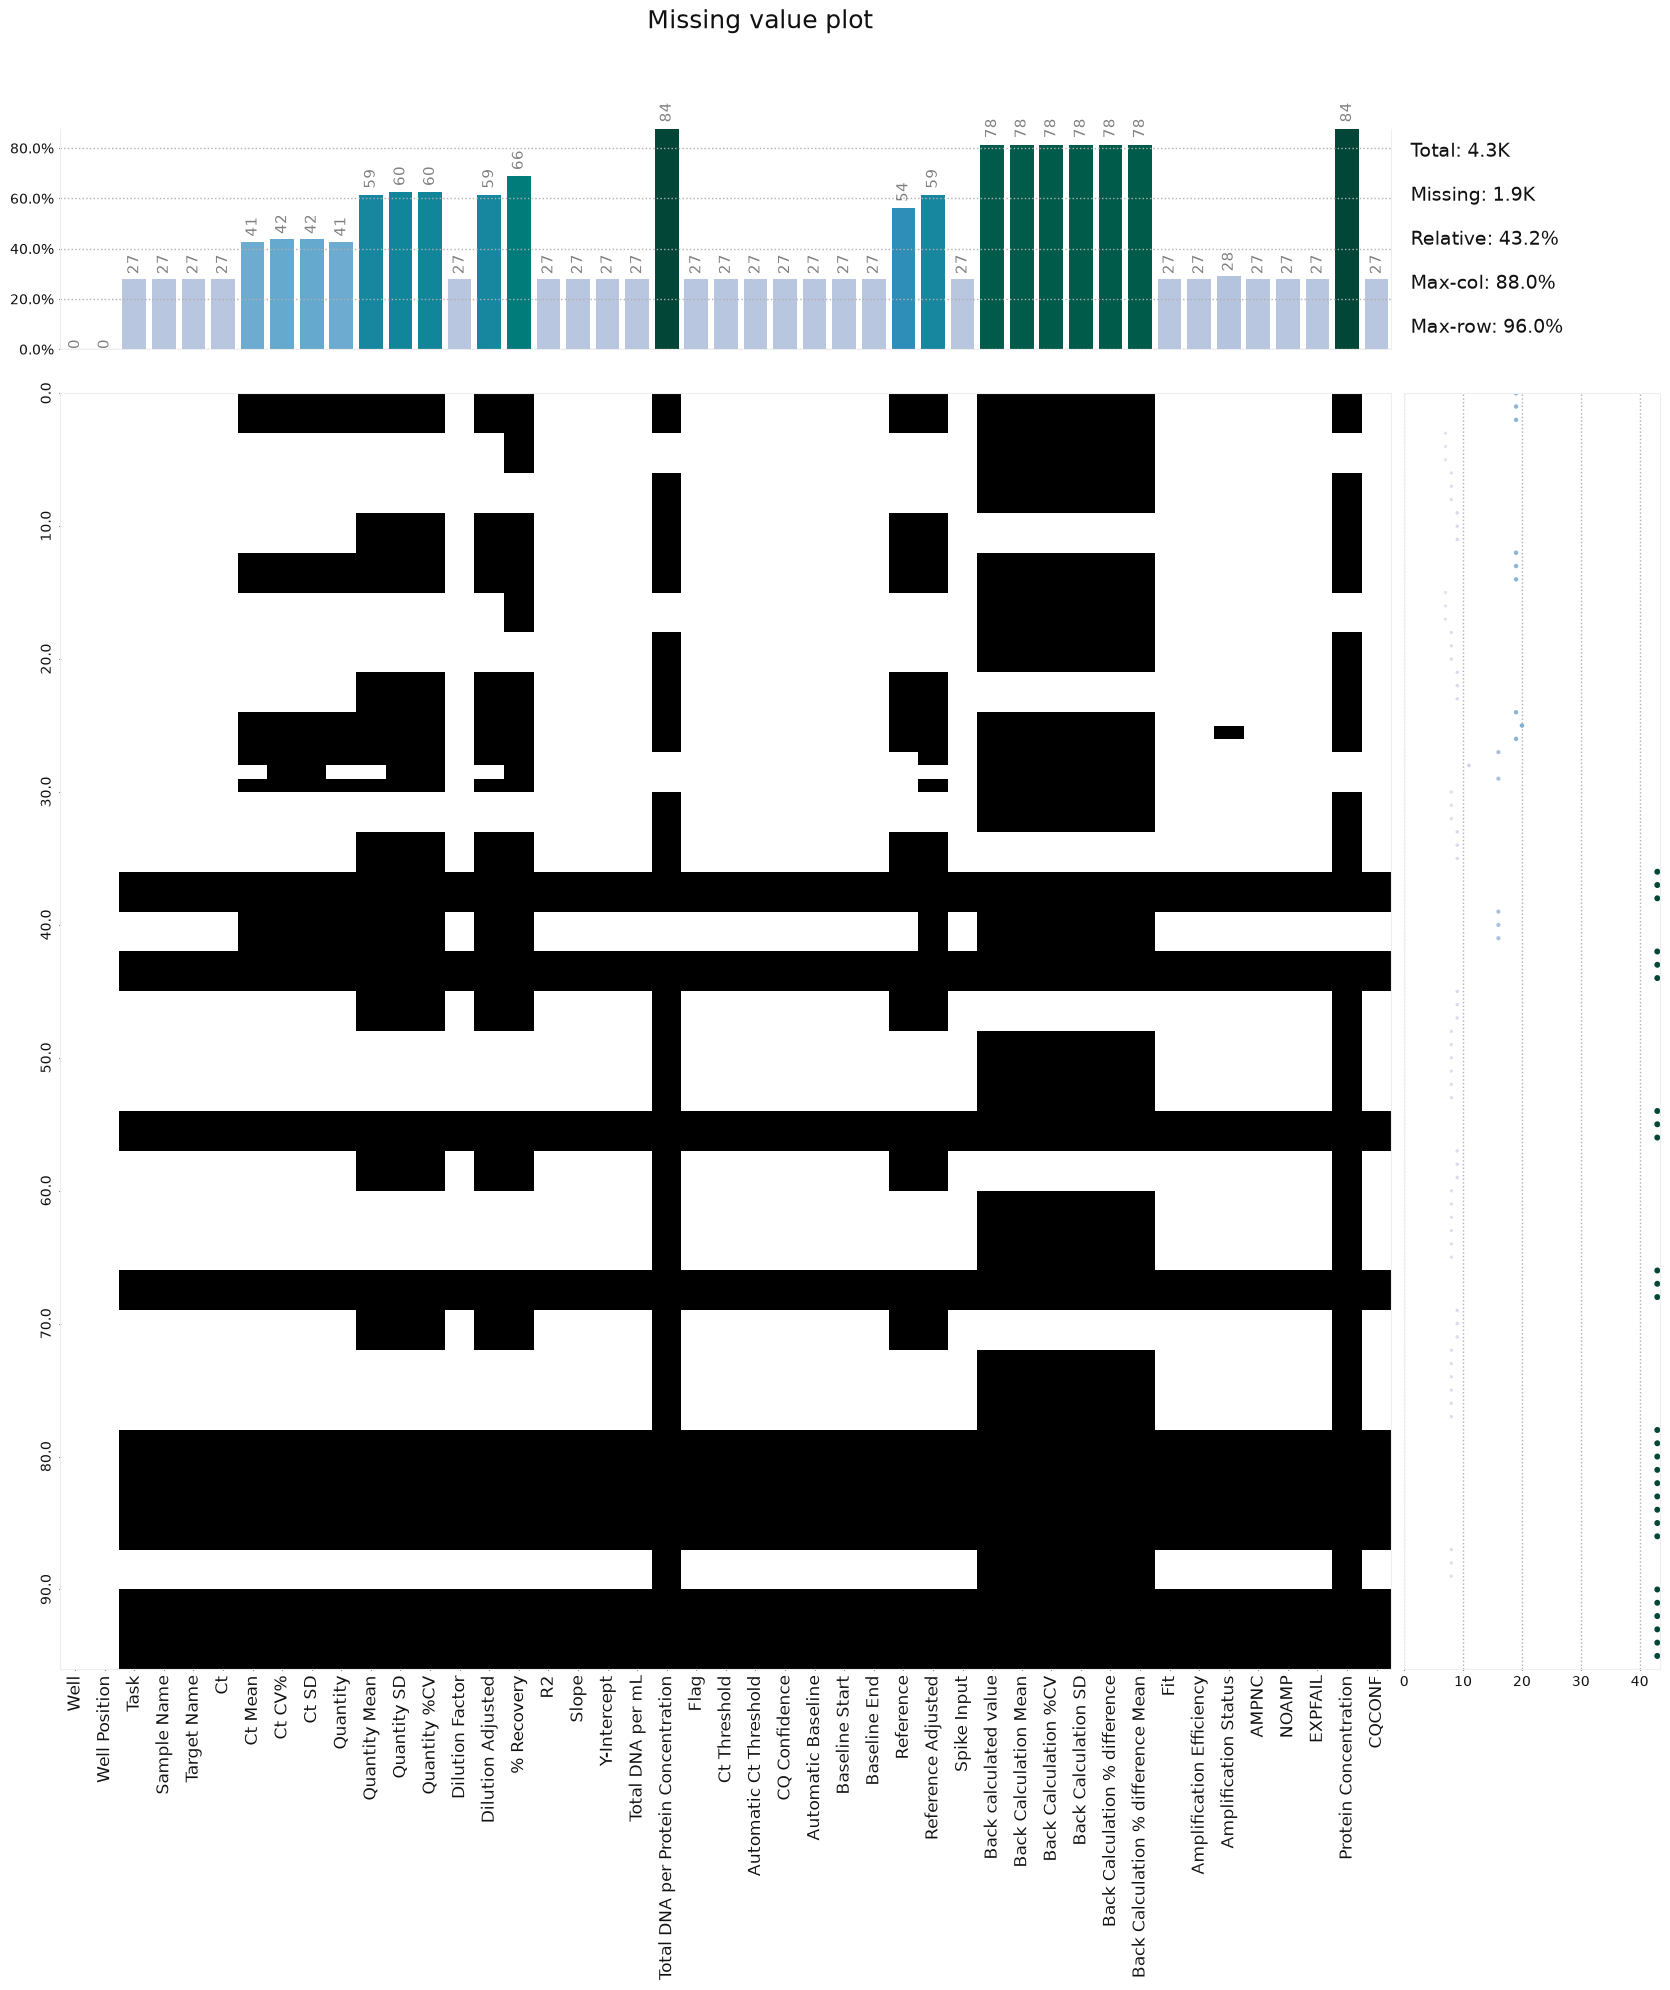

In [12]:
# Missing Value
klib.missingval_plot(df)

## QuantStudio Results Parser


```text
Results Parser
        │
        ├── Rename columns
        ├── Convert data types
        ├── Remove empty rows
        ├── Handle Undetermined Ct
        └── Produce standardized dataframe

```


### Rename or Standardize Columns

In [13]:
# Inspect attributes
print(df.columns.tolist())

['Well', 'Well Position', 'Task', 'Sample Name', 'Target Name', 'Ct', 'Ct Mean', 'Ct CV%', 'Ct SD', 'Quantity', 'Quantity Mean', 'Quantity SD', 'Quantity %CV', 'Dilution Factor', 'Dilution Adjusted', '% Recovery', 'R2', 'Slope', 'Y-Intercept', 'Total DNA per mL', 'Total DNA per Protein Concentration', 'Flag', 'Ct Threshold', 'Automatic Ct Threshold', 'CQ Confidence', 'Automatic Baseline', 'Baseline Start', 'Baseline End', 'Reference', 'Reference Adjusted', 'Spike Input', 'Back calculated value', 'Back Calculation Mean', 'Back Calculation %CV', 'Back Calculation SD', 'Back Calculation % difference', 'Back Calculation % difference Mean', 'Fit', 'Amplification Efficiency', 'Amplification Status', 'AMPNC', 'NOAMP', 'EXPFAIL', 'Protein Concentration', 'CQCONF']


In [14]:
# Standardize names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print(df.columns.tolist())

['well', 'well_position', 'task', 'sample_name', 'target_name', 'ct', 'ct_mean', 'ct_cv%', 'ct_sd', 'quantity', 'quantity_mean', 'quantity_sd', 'quantity_%cv', 'dilution_factor', 'dilution_adjusted', '%_recovery', 'r2', 'slope', 'y_intercept', 'total_dna_per_ml', 'total_dna_per_protein_concentration', 'flag', 'ct_threshold', 'automatic_ct_threshold', 'cq_confidence', 'automatic_baseline', 'baseline_start', 'baseline_end', 'reference', 'reference_adjusted', 'spike_input', 'back_calculated_value', 'back_calculation_mean', 'back_calculation_%cv', 'back_calculation_sd', 'back_calculation_%_difference', 'back_calculation_%_difference_mean', 'fit', 'amplification_efficiency', 'amplification_status', 'ampnc', 'noamp', 'expfail', 'protein_concentration', 'cqconf']


### Convert Data Type

In [15]:
# Convert columns to numeric
numeric_columns = [
    "ct",
    "ct_mean",
    "ct_sd",
    "quantity",
    "quantity_mean",
    "quantity_sd"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [16]:
# verify
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   well                                 96 non-null     str    
 1   well_position                        96 non-null     int64  
 2   task                                 69 non-null     str    
 3   sample_name                          69 non-null     str    
 4   target_name                          69 non-null     str    
 5   ct                                   60 non-null     float64
 6   ct_mean                              55 non-null     float64
 7   ct_cv%                               54 non-null     float64
 8   ct_sd                                54 non-null     float64
 9   quantity                             55 non-null     float64
 10  quantity_mean                        37 non-null     float64
 11  quantity_sd                          36 non-n

### Remove Empty Rows

In [17]:
# Clean the data or remove empty rows
df = klib.data_cleaning(df)

# Define output folder
#processed_path = project_path / "Processed_Data"
#processed_path.mkdir(exist_ok=True)

# Save
#output_file = processed_path / "experiment_001_cleaned.csv"
#df.to_csv(output_file, index=False)

#print(f"Saved to: {output_file}")

Shape of cleaned data: (69, 35) - Remaining NAs: 716


Dropped rows: 27
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 10
     of which 10 single valued.     Columns: ['target_name', 'r2', 'slope', 'y_intercept', 'ct_threshold', 'automatic_ct_threshold', 'automatic_baseline', 'baseline_start', 'fit', 'amplification_efficiency']
Dropped missing values: 1161
Reduced memory by at least: 0.02 MB (-66.67%)



### Transform Ct values into numeric ("Undetermined")

In [18]:
### Replace "Undetermined"
df["ct"] = (
    df["ct"]
      .replace("Undetermined", pd.NA)
)

df["ct"] = pd.to_numeric(df["ct"])

### Parser Summary

In [19]:
print("========== Results Parser ==========")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Missing Ct values: {df['ct'].isna().sum()}")
print(f"Unique Samples: {df['sample_name'].nunique()}")
print(f"Unique Task: {df['task'].nunique()}")

========== Results Parser ==========
Rows: 69
Columns: 35
Missing Ct values: 9
Unique Samples: 23
Unique Task: 3


### Standardized Dataset - parsed_df

In [20]:
parsed_df = df.copy()
style_table(parsed_df.head(), caption="Standardized Dataset Preview")

#output_file = processed_path / "experiment_001_parsed.csv"
#df.to_csv(output_file, index=False)
#print(f"Saved: {output_file}")

well,well_position,task,sample_name,ct,ct_mean,ct_cv_percent,ct_sd,quantity,quantity_mean,quantity_sd,quantity_percent_cv,dilution_factor,dilution_adjusted,percent_recovery,total_dna_per_ml,total_dna_per_protein_concentration,flag,cq_confidence,baseline_end,reference,reference_adjusted,spike_input,back_calculated_value,back_calculation_mean,back_calculation_percent_cv,back_calculation_sd,back_calculation_percent_difference,back_calculation_percent_difference_mean,amplification_status,ampnc,noamp,expfail,protein_concentration,cqconf
A1,1,NTC,NTC,—,—,—,—,—,—,—,—,1.0000,—,—,0.0000,—,0.0000,0.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,No Amp,N,N,N,—,N
A2,2,NTC,NTC,—,—,—,—,—,—,—,—,1.0000,—,—,0.0000,—,0.0000,0.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,No Amp,N,N,N,—,N
A3,3,NTC,NTC,—,—,—,—,—,—,—,—,1.0000,—,—,0.0000,—,0.0000,0.0000,39.0000,—,—,0.0000,—,—,—,—,—,—,No Amp,N,N,N,—,N
A4,4,UNKNOWN,S1 D1,32.3647,32.5183,0.8100,0.2622,0.0004,0.0004,0.0001,17.2400,1.0000,0.0004,—,0.0004,0.0002,0.0000,1.0000,27.0000,0.0000,0.0004,0.0000,—,—,—,—,—,—,Amplification,N,N,N,1.8250,N
A5,5,UNKNOWN,S1 D1,32.3692,32.5183,0.8100,0.2622,0.0004,0.0004,0.0001,17.2400,1.0000,0.0004,—,0.0004,0.0002,0.0000,1.0000,28.0000,0.0000,0.0004,0.0000,—,—,—,—,—,—,Amplification,N,N,N,1.8250,N


## Data Classification Engine

```text
Classification Engine
        │
        ├── Reference Standard   (STD curve points)
        ├── Controls
        │     ├── NTC   No Template Control
        │     ├── NEC   No Extraction Control
        │     ├── ERC   Extraction Recovery Control
        │     └── PC    Positive Control (HPC / MPC / LPC)
        └── Sample(s)             (unknowns)

```

### Classify Task / Sample Name

In [21]:
# Classify each well into Reference Standard, Control, or Sample
def classify_sample(sample_name, task):
    name = str(sample_name).strip().upper()

    if task == "STANDARD" or name.startswith("STD"):
        return pd.Series(["Reference Standard", "STD"])
    if name.startswith("NTC"):
        return pd.Series(["Control", "NTC"])
    if name.startswith("NEC"):
        return pd.Series(["Control", "NEC"])
    if name.startswith("ERC"):
        return pd.Series(["Control", "ERC"])
    if name.startswith("HPC"):
        return pd.Series(["Control", "HPC"])
    if name.startswith("MPC"):
        return pd.Series(["Control", "MPC"])
    if name.startswith("LPC"):
        return pd.Series(["Control", "LPC"])
    return pd.Series(["Sample", "Sample"])

parsed_df[["sample_group", "control_type"]] = parsed_df.apply(
    lambda row: classify_sample(row["sample_name"], row["task"]),
    axis=1
)

classification_table = (
    parsed_df[["sample_name", "task", "sample_group", "control_type"]]
    .drop_duplicates()
    .sort_values(["sample_group", "control_type", "sample_name"])
    .reset_index(drop=True)
)

style_table(classification_table, caption="Sample Classification", align="left")

sample_name,task,sample_group,control_type
ERC - 10,UNKNOWN,Control,ERC
ERC - 30,UNKNOWN,Control,ERC
ERC - 60,UNKNOWN,Control,ERC
HPC - 190,UNKNOWN,Control,HPC
LPC - 5,UNKNOWN,Control,LPC
MPC - 10,UNKNOWN,Control,MPC
NEC - FB,NTC,Control,NEC
NEC - PBS,NTC,Control,NEC
NTC,NTC,Control,NTC
STD 0.003,STANDARD,Reference Standard,STD


### Split by Group

In [22]:
# Split the standardized dataset into its three groups
ref_std_df = parsed_df[parsed_df["sample_group"] == "Reference Standard"].copy()
controls_df = parsed_df[parsed_df["sample_group"] == "Control"].copy()
samples_df = parsed_df[parsed_df["sample_group"] == "Sample"].copy()

### Classification Summary

In [23]:
# Summarize each group as a presentable table
summary_table = (
    parsed_df
    .groupby(["sample_group", "control_type"], as_index=False)
    .agg(**{
        "Unique Samples": ("sample_name", "nunique"),
        "Rows": ("sample_name", "size"),
    })
    .rename(columns={"sample_group": "Group", "control_type": "Subtype"})
)

total_row = pd.DataFrame([{
    "Group": "Total",
    "Subtype": "",
    "Unique Samples": parsed_df["sample_name"].nunique(),
    "Rows": len(parsed_df),
}])

summary_table = pd.concat([summary_table, total_row], ignore_index=True)

style_table(summary_table, caption="Data Classification Summary", precision=0, align="left")

Group,Subtype,Unique Samples,Rows
Control,ERC,3,9
Control,HPC,1,3
Control,LPC,1,3
Control,MPC,1,3
Control,NEC,2,6
Control,NTC,1,3
Reference Standard,STD,6,18
Sample,Sample,8,24
Total,,23,69


## System Suitability Engine

```text
System Suitability Engine
        │
        ├── STD Curve      R² > 0.99, Efficiency 90-110%,
        │                 Ct %CV ≤ 20%, Back-Calc %Bias < 25%
        ├── ERC / PC       Quantity %CV < 20%, %Recovery in range
        └── NTC / NEC      NTC undetermined; NEC undetermined or Ct ≥ LOQ Ct

```

### Acceptance Criteria

In [24]:
# STD curve
STD_R2_MIN = 0.99
STD_CT_CV_MAX = 20.0
STD_BACK_CALC_BIAS_MAX = 25.0
STD_EFFICIENCY_MIN = 90.0
STD_EFFICIENCY_MAX = 110.0

# ERC / PC controls
CTRL_QTY_CV_MAX = 20.0
PC_RECOVERY_MIN, PC_RECOVERY_MAX = 80.0, 120.0
ERC_RECOVERY_MIN, ERC_RECOVERY_MAX = 50.0, 150.0

# ICH Q2(R1) / USP <1225>: LOD = 3.3*sigma/|slope|, LOQ = 10*sigma/|slope|
# sigma = residual standard deviation of the regression line ("Std error")
LOD_SIGMA_MULTIPLIER = 3.3
LOQ_SIGMA_MULTIPLIER = 10.0

### Standard Curve Statistics

In [25]:
# Pull the curve statistics already captured in regression_table
reg_stats = regression_table.set_index("Metric")["Value"].astype(float)

curve_r2 = reg_stats["R2"]
curve_slope = reg_stats["Slope"]
curve_intercept = reg_stats["y-Intercept"]
curve_efficiency = reg_stats["Efficiency"]
curve_std_error = reg_stats["Std error"]

# Convert the sigma/slope offset (log10 quantity) back into Ct space via the curve equation
lod_log_qty = LOD_SIGMA_MULTIPLIER * curve_std_error / abs(curve_slope)
loq_log_qty = LOQ_SIGMA_MULTIPLIER * curve_std_error / abs(curve_slope)

lod_ct = curve_slope * lod_log_qty + curve_intercept
loq_ct = curve_slope * loq_log_qty + curve_intercept

print(f"R²={curve_r2}  Slope={curve_slope}  Intercept={curve_intercept}  "
      f"Efficiency={curve_efficiency}%  Std Error={curve_std_error}")
print(f"LOD Ct = {lod_ct:.4f}   LOQ Ct = {loq_ct:.4f}")

R²=0.9998  Slope=-3.3008  Intercept=21.3153  Efficiency=100.89%  Std Error=0.0116
LOD Ct = 21.2770   LOQ Ct = 21.1993


### STD Curve Suitability

In [26]:
curve_checks = pd.DataFrame([
    {
        "Check": "R² > 0.99",
        "Value": curve_r2,
        "Pass": curve_r2 > STD_R2_MIN,
    },
    {
        "Check": "Amplification Efficiency 90-110%",
        "Value": curve_efficiency,
        "Pass": STD_EFFICIENCY_MIN <= curve_efficiency <= STD_EFFICIENCY_MAX,
    },
])

style_table(curve_checks, caption="Standard Curve Suitability", align="left")

Check,Value,Pass
R² > 0.99,0.9998,True
Amplification Efficiency 90-110%,100.8900,True


### STD Curve Point Suitability

In [27]:
std_suitability = (
    ref_std_df
    .groupby("sample_name", as_index=False)
    .agg(**{
        "Quantity": ("quantity", "first"),
        "Ct %CV": ("ct_cv_percent", "first"),
        "Back-Calc %Bias": ("back_calculation_percent_difference_mean", "first"),
    })
    .sort_values("Quantity")
    .reset_index(drop=True)
)

std_suitability["Ct %CV Pass"] = std_suitability["Ct %CV"] <= STD_CT_CV_MAX
std_suitability["Back-Calc Pass"] = std_suitability["Back-Calc %Bias"].abs() < STD_BACK_CALC_BIAS_MAX

style_table(
    std_suitability.rename(columns={"sample_name": "Sample"}),
    caption="Standard Curve Point Suitability",
    align="left",
)

Sample,Quantity,Ct %CV,Back-Calc %Bias,Ct %CV Pass,Back-Calc Pass
STD 0.003,0.0030,0.4700,5.0557,True,True
STD 0.03,0.0300,0.1100,-4.0363,True,True
STD 0.3,0.3000,0.2900,-1.7549,True,True
STD 3,3.0000,0.3400,-2.8479,True,True
STD 30,30.0000,0.1900,-1.2517,True,True
STD 300,300.0000,0.4600,3.9324,True,True


### ERC & PC Suitability

In [28]:
control_suitability = (
    controls_df[controls_df["control_type"].isin(["ERC", "HPC", "MPC", "LPC"])]
    .groupby(["control_type", "sample_name"], as_index=False)
    .agg(**{
        "Quantity %CV": ("quantity_percent_cv", "first"),
        "% Recovery": ("percent_recovery", "first"),
    })
)

def recovery_bounds(control_type):
    if control_type in ("HPC", "MPC", "LPC"):
        return PC_RECOVERY_MIN, PC_RECOVERY_MAX
    return ERC_RECOVERY_MIN, ERC_RECOVERY_MAX

control_suitability["CV Pass"] = control_suitability["Quantity %CV"] <= CTRL_QTY_CV_MAX
control_suitability["Recovery Pass"] = control_suitability.apply(
    lambda row: recovery_bounds(row["control_type"])[0]
    <= row["% Recovery"]
    <= recovery_bounds(row["control_type"])[1],
    axis=1,
)

style_table(
    control_suitability.rename(columns={"control_type": "Control Type", "sample_name": "Sample"}),
    caption="ERC & PC Suitability",
    align="left",
)

Control Type,Sample,Quantity %CV,% Recovery,CV Pass,Recovery Pass
ERC,ERC - 10,1.1200,68.5800,True,True
ERC,ERC - 30,1.9100,66.9100,True,True
ERC,ERC - 60,3.0600,70.8400,True,True
HPC,HPC - 190,10.2600,112.8800,True,True
LPC,LPC - 5,0.7000,109.6700,True,True
MPC,MPC - 10,5.1700,109.8700,True,True


### NTC & NEC Suitability

In [29]:
ntc_df = controls_df[controls_df["control_type"] == "NTC"]
ntc_pass = ntc_df["ct"].isna().all()

# NEC passes per well if Ct is undetermined, or at/below the assay's quantifiable sensitivity
# (i.e. Ct at or later than the LOQ Ct — lower concentration than the LOQ)
nec_df = controls_df[controls_df["control_type"] == "NEC"].copy()
nec_df["well_pass"] = nec_df["ct"].isna() | (nec_df["ct"] >= loq_ct)

nec_summary = (
    nec_df.groupby("sample_name", as_index=False)
    .agg(**{"Wells Passing": ("well_pass", "sum"), "Total Wells": ("well_pass", "size")})
)
nec_summary["Pass"] = nec_summary["Wells Passing"] == nec_summary["Total Wells"]
nec_summary = nec_summary.rename(columns={"sample_name": "Sample"})

negative_control_summary = pd.concat(
    [
        pd.DataFrame([{
            "Sample": "NTC (all wells)",
            "Wells Passing": int(ntc_df["ct"].isna().sum()),
            "Total Wells": len(ntc_df),
            "Pass": ntc_pass,
        }]),
        nec_summary,
    ],
    ignore_index=True,
)

style_table(
    negative_control_summary,
    caption=f"Negative Control Suitability (LOQ Ct = {loq_ct:.2f})",
    align="left",
    precision=0,
)

Sample,Wells Passing,Total Wells,Pass
NTC (all wells),3,3,True
NEC - FB,3,3,True
NEC - PBS,3,3,True


### System Suitability Summary

In [30]:
system_suitability_pass = bool(
    (curve_r2 > STD_R2_MIN)
    and (STD_EFFICIENCY_MIN <= curve_efficiency <= STD_EFFICIENCY_MAX)
    and std_suitability["Ct %CV Pass"].all()
    and std_suitability["Back-Calc Pass"].all()
    and control_suitability["CV Pass"].all()
    and control_suitability["Recovery Pass"].all()
    and ntc_pass
    and nec_summary["Pass"].all()
)

status = "PASS" if system_suitability_pass else "FAIL"
print(f"========== System Suitability: {status} ==========")

========== System Suitability: PASS ==========


## Sample Result Processing

```text
Sample Suitability Checks
        │
        ├── Quantity %CV          triplicate %CV < 20%
        └── Dilutional Linearity  spike-adjusted %Bias < 20% across D1-D4

```

### Acceptance Criteria

In [31]:
SAMPLE_QTY_CV_MAX = 20.0
SAMPLE_LINEARITY_BIAS_MAX = 20.0

### Sample %CV Suitability

In [32]:
sample_cv = (
    samples_df
    .groupby("sample_name", as_index=False)
    .agg(**{"Quantity %CV": ("quantity_percent_cv", "first")})
    .sort_values("sample_name")
    .reset_index(drop=True)
)

sample_cv["Pass"] = (sample_cv["Quantity %CV"] <= SAMPLE_QTY_CV_MAX).astype(object)
# Below-LOQ / non-amplifying replicates have no %CV to evaluate — mark as N/A rather than fail
sample_cv.loc[sample_cv["Quantity %CV"].isna(), "Pass"] = pd.NA

style_table(
    sample_cv.rename(columns={"sample_name": "Sample"}),
    caption="Sample %CV Suitability (Triplicate Quantity)",
    align="left",
)

Sample,Quantity %CV,Pass
S1 D1,17.2400,True
S1 D1 S,2.9000,True
S1 D2,21.5200,False
S1 D2 S,2.6900,True
S1 D3,—,—
S1 D3 S,1.6700,True
S1 D4,—,—
S1 D4 S,2.9700,True


### Dilutional Linearity Suitability

In [33]:
# Recommended approach: compare each dilution's spike-adjusted %Recovery to 100%.
# Only the spiked dilution series (D1 S - D4 S) carries a reference/expected value.
linearity_df = (
    samples_df[samples_df["percent_recovery"].notna()]
    .groupby("sample_name", as_index=False)
    .agg(**{"% Recovery": ("percent_recovery", "first")})
    .sort_values("sample_name")
    .reset_index(drop=True)
)

linearity_df["% Bias"] = (linearity_df["% Recovery"] - 100).abs()
linearity_df["Pass"] = linearity_df["% Bias"] < SAMPLE_LINEARITY_BIAS_MAX

style_table(
    linearity_df.rename(columns={"sample_name": "Sample"}),
    caption="Dilutional Linearity Suitability (D1–D4, spike-adjusted)",
    align="left",
)

Sample,% Recovery,% Bias,Pass
S1 D1 S,108.8800,8.8800,True
S1 D2 S,104.7000,4.7000,True
S1 D3 S,103.1700,3.1700,True
S1 D4 S,102.4100,2.4100,True


### Sample Suitability Summary

In [34]:
sample_suitability_pass = bool(
    sample_cv["Pass"].fillna(True).all() and linearity_df["Pass"].all()
)

status = "PASS" if sample_suitability_pass else "FAIL"
print(f"========== Sample Suitability: {status} ==========")

========== Sample Suitability: FAIL ==========


### Final Sample Results

In [35]:
# Report the full unspiked dilution series (D1-D4); the spiked series is ignored for now.
# Every dilution is listed for traceability, but only suitability-passing dilutions are
# tallied as reportable results.
SAMPLE_DNA_PER_PROTEIN_LIMIT = 15.0  # ng/mg

unspiked_samples = samples_df[~samples_df["sample_name"].str.endswith(" S")].copy()

final_results = (
    unspiked_samples
    .drop_duplicates(subset="sample_name")
    [[
        "sample_name",
        "dilution_factor",
        "quantity_percent_cv",
        "total_dna_per_ml",
        "protein_concentration",
        "total_dna_per_protein_concentration",
    ]]
    .rename(columns={
        "sample_name": "Sample",
        "dilution_factor": "Dilution Factor",
        "quantity_percent_cv": "Quantity %CV",
        "total_dna_per_ml": "Total DNA (ng/mL)",
        "protein_concentration": "Protein Concentration (mg/mL)",
        "total_dna_per_protein_concentration": "Total DNA per Protein (ng/mg)",
    })
    .sort_values("Sample")
    .reset_index(drop=True)
)

# A missing %CV means there is no evaluable triplicate (below LOQ / no amplification)
final_results["Suitability"] = final_results["Quantity %CV"].apply(
    lambda cv: "N/A" if pd.isna(cv) else ("Pass" if cv <= SAMPLE_QTY_CV_MAX else "Fail")
)

# Only suitability-passing dilutions are reported; flag those below the residual DNA limit
def result_status(row):
    if row["Suitability"] != "Pass":
        return "Not Reported"
    value = row["Total DNA per Protein (ng/mg)"]
    if pd.isna(value):
        return "N/A"
    return "Below" if value < SAMPLE_DNA_PER_PROTEIN_LIMIT else "Above"

final_results["Status"] = final_results.apply(result_status, axis=1)

# Suitability-passing subset carried forward as the reportable result
reportable_results = final_results[final_results["Suitability"] == "Pass"].reset_index(drop=True)

print(f"Reported dilutions: {reportable_results['Sample'].tolist()}")
print(f"Excluded dilutions: {final_results.loc[final_results['Suitability'] != 'Pass', 'Sample'].tolist()}")

style_table(
    final_results,
    caption=(
        f"Final Sample Results (Unspiked D1-D4) — "
        f"reported rows below {SAMPLE_DNA_PER_PROTEIN_LIMIT:.0f} ng/mg highlighted"
    ),
    align="left",
    highlight_rows=final_results["Status"] == "Below",
)

Reported dilutions: ['S1 D1']
Excluded dilutions: ['S1 D2', 'S1 D3', 'S1 D4']


Sample,Dilution Factor,Quantity %CV,Total DNA (ng/mL),Protein Concentration (mg/mL),Total DNA per Protein (ng/mg),Suitability,Status
S1 D1,1.0000,17.2400,0.0004,1.8250,0.0002,Pass,Below
S1 D2,10.0000,21.5200,0.0004,1.8250,0.0002,Fail,Not Reported
S1 D3,100.0000,—,0.0007,1.8250,0.0004,N/A,Not Reported
S1 D4,1000.0000,—,0.0000,1.8250,0.0000,N/A,Not Reported


## Create Prototype Graphs

##